# Análise do Consumo de Água em Parques: Regressão Linear

## Introdução

Este estudo visa analisar a relação entre a área dos parques e o consumo médio mensal de água, utilizando dados dos ficheiros `Area.csv` e `water_consumption_updated.csv`. A empresa gestora de parques está a considerar a administração de um novo parque com 55 hectares e pretende prever o custo médio mensal associado ao consumo de água.

Para tal, aplicaremos um modelo de regressão linear, considerando a área do parque como a variável independente e o consumo médio mensal de água como a variável dependente. Este estudo inclui:

1. **Preparação dos dados**: Conversão de formatos e cálculo do consumo médio mensal.
2. **Análise exploratória**: Visualização da relação entre a área do parque e o consumo de água.
3. **Aplicação do modelo de regressão linear**: Cálculo da linha de regressão e análise dos resíduos.
4. **Previsão para o novo parque**: Cálculo do valor previsto e dos intervalos de confiança e predição.

## Objetivos

- Prever o consumo médio mensal de água para um parque de 55 hectares.
- Avaliar a precisão da previsão utilizando intervalos de confiança e predição.
- Determinar a adequação do modelo de regressão linear para a gestão de novos parques.

## Dados

- `Area.csv`: Contém a área (em hectares) de cada parque.
- `water_consumption_updated.csv`: Contém o consumo diário de água de vários parques.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress, pearsonr
from scipy import stats

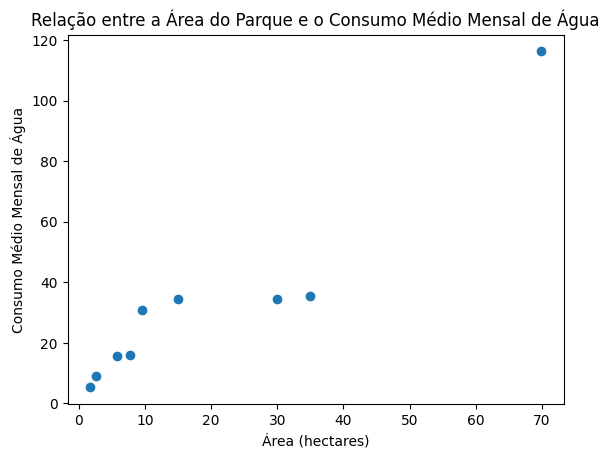

In [20]:
# Carregar os dados
area_df = pd.read_csv('Area.csv', delimiter=';')
water_consumption_df = pd.read_csv('water_consumption_updated.csv', delimiter=';')

# Converter vírgulas para pontos e os valores para float
area_df['Area'] = area_df['Area'].str.replace(',', '.').astype(float)
water_consumption_df['Consumption'] = water_consumption_df['Consumption'].str.replace(',', '.').astype(float)

# Calcular o consumo médio mensal para cada parque
monthly_consumption = water_consumption_df.groupby('Park')['Consumption'].mean().reset_index()

# Unir os dados de área com os dados de consumo
merged_df = pd.merge(area_df, monthly_consumption, on='Park')

# Aplicar a regressão linear
x = merged_df['Area'].to_numpy()
y = merged_df['Consumption'].to_numpy()
n = len(x)

# Plot dos dados originais
plt.plot(x, y, 'o')
plt.xlabel('Área (hectares)')
plt.ylabel('Consumo Médio Mensal de Água')
plt.title('Relação entre a Área do Parque e o Consumo Médio Mensal de Água')
plt.show()


**Conclusão Inicial**: A partir do gráfico acima, podemos observar uma relação positiva entre a área do parque e o consumo médio mensal de água. Parques maiores tendem a consumir mais água.

In [21]:

# Calcular coeficiente de correlação
r = pearsonr(x, y)
print(f'Correlation Coefficient r = {r[0]:.3f}')


Correlation Coefficient r = 0.948


**Conclusão sobre Correlação**: O coeficiente de correlação r=0.948r=0.948 indica uma forte correlação positiva entre a área do parque e o consumo médio mensal de água, sugerindo que uma regressão linear pode ser apropriada.

A linha de regressão é y = 5.054 + 1.422x


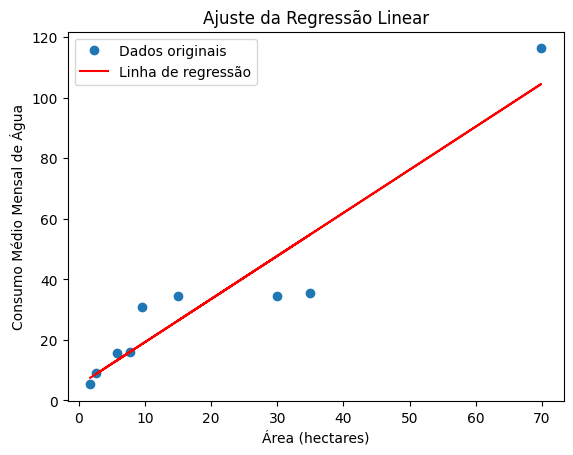

In [22]:

# Calcular a linha de regressão
model = linregress(x, y)
print(f'A linha de regressão é y = {model.intercept:.3f} + {model.slope:.3f}x')

# Plot da linha de regressão
plt.plot(x, y, 'o', label='Dados originais')
plt.plot(x, model.intercept + model.slope * x, 'r', label='Linha de regressão')
plt.xlabel('Área (hectares)')
plt.ylabel('Consumo Médio Mensal de Água')
plt.title('Ajuste da Regressão Linear')
plt.legend()
plt.show()

**Conclusão sobre Regressão Linear**: A linha de regressão ajustada indica que, para cada hectare adicional, o consumo médio mensal de água aumenta em aproximadamente 1.422 unidades. A linha ajusta-se bem aos dados, confirmando a viabilidade do modelo linear.

In [23]:
# Previsão para x0 = 55 hectares
x0 = 55
expected_value = model.intercept + model.slope * x0
print(f'Se a área do parque é 55 hectares, o consumo médio mensal esperado de água é {expected_value:.2f}')


Se a área do parque é 55 hectares, o consumo médio mensal esperado de água é 83.28


**Conclusão sobre Previsão**: Para um parque de 55 hectares, o consumo médio mensal previsto de água é de 83.28 unidades.

In [24]:

# Calcular intervalo de confiança e de predição
xbar = x.mean()
ybar = y.mean()
sxx = np.sum((x - xbar) ** 2)
syy = np.sum((y - ybar) ** 2)
sxy = np.sum((y - ybar) * (x - xbar))
sqe = syy - sxy ** 2 / sxx
s_sqr = sqe / (n - 2)
alpha = 1 - 0.95
t = stats.t.ppf(1 - alpha / 2, n - 2)

# Intervalo de confiança
delta_ci = t * np.sqrt(s_sqr * (1 / n + (x0 - xbar) ** 2 / sxx))
CI = [expected_value - delta_ci, expected_value + delta_ci]
print(f'95% IC para E(Y|x=55) é [{CI[0]:.2f}, {CI[1]:.2f}]')

# Intervalo de predição
delta_pi = t * np.sqrt(s_sqr * (1 + 1 / n + (x0 - xbar) ** 2 / sxx))
PI = [expected_value - delta_pi, expected_value + delta_pi]
print(f'95% PI para y(55) é [{PI[0]:.2f}, {PI[1]:.2f}]')

95% IC para E(Y|x=55) é [65.69, 100.88]
95% PI para y(55) é [51.13, 115.44]


### Intervalo de Confiança (IC) para a Média do Consumo

O intervalo de confiança para a média do consumo de água, considerando um parque com 55 hectares, é [65.69, 100.88]. Este intervalo fornece uma estimativa da média esperada do consumo mensal de água para parques com esta dimensão, com um nível de confiança de 95%.

- **Significado**: Estamos 95% confiantes de que a verdadeira média do consumo mensal de água para todos os parques de 55 hectares se encontra dentro deste intervalo.

### Intervalo de Predição (IP) para um Valor Individual do Consumo

O intervalo de predição para o consumo mensal de água de um parque específico de 55 hectares é [51.13, 115.44]. Este intervalo fornece uma estimativa da faixa em que um novo valor individual do consumo mensal de água pode situar-se, com um nível de confiança de 95%.

- **Significado**: Estamos 95% confiantes de que o consumo mensal de água para um parque específico de 55 hectares estará dentro deste intervalo.

### Conclusão

- **Acuracidade da Média**: O intervalo de confiança [65.69, 100.88] assegura-nos que a média do consumo de água está corretamente estimada, porque o valor previsto de 83.28 unidades está dentro deste intervalo. Isto confirma que o modelo de regressão linear está a fornecer uma estimativa precisa da média do consumo para parques de 55 hectares.
- **Consideração da Variabilidade Individual**: O intervalo de predição [51.13, 115.44] mostra que a variabilidade individual dos consumos está devidamente considerada. A previsão de 83.28 unidades está dentro deste intervalo, indicando que o modelo é robusto e pode acomodar a variabilidade observada nos dados individuais, mantendo a fiabilidade da previsão.


## Conclusão Geral

A análise dos dados confirmou que existe uma forte correlação positiva entre a área do parque e o consumo médio mensal de água. A aplicação do modelo de regressão linear resultou na equação \( y = 5.054 + 1.422x \). Para um parque de 55 hectares, o consumo médio mensal previsto de água é de 83.28 unidades. O intervalo de confiança a 95% para a média do consumo é [65.69, 100.88], e o intervalo de predição a 95% para um valor individual do consumo é [51.13, 115.44]. Isto demonstra que a área do parque é um bom preditor do consumo de água, e que a regressão linear é adequada para fazer previsões para novos parques.